# <p style="text-align: center; color: red;"> Modelling and Control of Cement Emissions using ML</p> 

# <p style="text-align: left; color: yellow;"> Sheikh Junaid Fayaz -- M3RG Lab -- Indian Institute of Technology, Delhi</p> 
# <p style="text-align: left; color: yellow;"> Date : 06 March 2026</p> 

In [ ]:
import sys
sys.path.append('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks')
import functions  # First import
import importlib
importlib.reload(functions)  # Reload to reflect changes
from functions import *  # Now import updated functions

#add_custom_fonts(loc=".myfonts")
# import subprocess
# from shadow.plot import *
# from new_plot import * #This line is throwing an error #Solved by commenting out some of the keys of rcParams()

# Read data

In [2]:
filtered_palnt_d = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/filtered_plant_d_co.pkl')
np.random.seed(1002)
random.seed(0)

X = filtered_palnt_d.iloc[:,1:]
y = filtered_palnt_d.iloc[:,[0]]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=100)

# All model training (CO)

### SVR works best

In [3]:
titles = ['Linear regression', 'Lasso', 'Ridge', 'Elastic net', 'Random forest', 'XGBoost', 'SVR', 'GPR', 'NN']

In [4]:
train_scores = []
val_scores = []
test_scores = []

# LR

LinearRegression()

Avg Training:  R^2 = 0.49, MAE = 23.06, MAPE = 19.39%
Avg Val:  R^2 = 0.37, MAE = 25.01, MAPE = 20.94%
Test 0.44 23.08 20.57


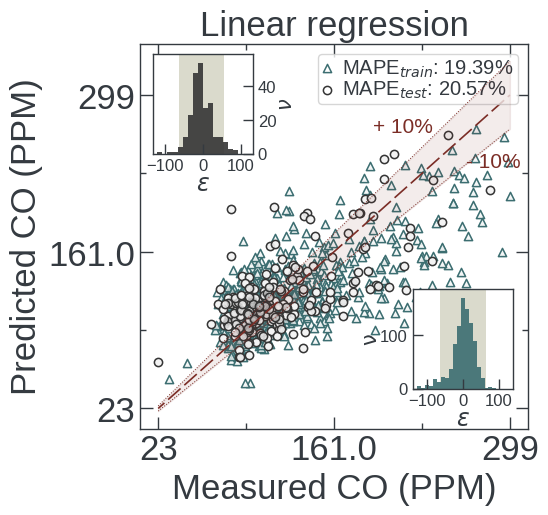

In [5]:
best_regressor = LinearRegression()
best_regressor.fit(X_train, y_train)

avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)  
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant4/{titles[0]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[0],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# Lasso

GPU 0: Utilization: 0%, Memory Used: 467 MB / 12282 MB
Fitting 1 folds for each of 4 candidates, totalling 4 fits
[CV] END ........................................alpha=1e-05; total time=   0.0s
[CV] END .......................................alpha=0.0001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s


{'alpha': 0.1}

GPU 0: Utilization: 0%, Memory Used: 467 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 467 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 467 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 0.0813 s
System CPU time  : 0.0202 s
Total CPU time   : 0.1015 s
Wall clock time  : 0.5520 s

---- CPU Utilization Stats ----
Avg CPU usage    : 0.00%
Max CPU usage    : 0.00%
Logical cores    : 64
Physical cores   : 32
Avg Training:  R^2 = 0.49, MAE = 23.07, MAPE = 19.41%
Avg Val:  R^2 = 0.37, MAE = 25.03, MAPE = 20.98%
Test 0.44 23.06 20.66


X has feature names, but Lasso was fitted without feature names
X has feature names, but Lasso was fitted without feature names
X has feature names, but Lasso was fitted without feature names


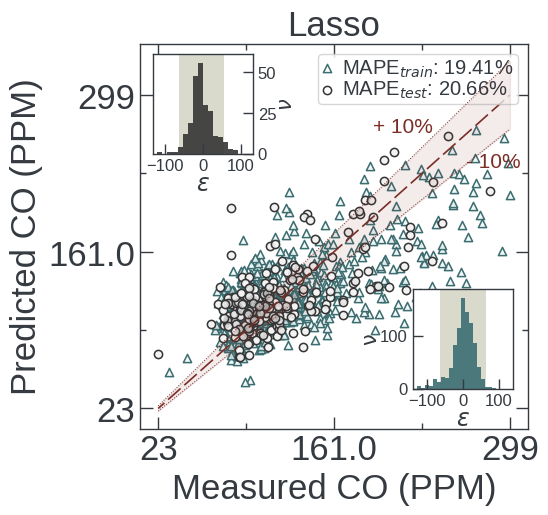

In [6]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = Lasso()
hyperparameter_grid= {'alpha': [0.00001, 0.0001,0.001, 0.1]} 
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = 4, verbose= 2)
random_search.best_params_
end_profiling(save_path = None, note = None)

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= None)
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant4/{titles[1]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[1],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

# Ridge

GPU 0: Utilization: 0%, Memory Used: 467 MB / 12282 MB
Fitting 1 folds for each of 4 candidates, totalling 4 fits
[CV] END ........................................alpha=1e-05; total time=   0.0s
[CV] END .......................................alpha=0.0001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s


{'alpha': 0.1}

GPU 0: Utilization: 0%, Memory Used: 467 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 467 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 467 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 0.0237 s
System CPU time  : 0.0230 s
Total CPU time   : 0.0467 s
Wall clock time  : 0.5569 s

---- CPU Utilization Stats ----
Avg CPU usage    : 0.00%
Max CPU usage    : 0.00%
Logical cores    : 64
Physical cores   : 32
Avg Training:  R^2 = 0.49, MAE = 23.06, MAPE = 19.39%
Avg Val:  R^2 = 0.37, MAE = 25.01, MAPE = 20.94%
Test 0.44 23.08 20.57


X has feature names, but Ridge was fitted without feature names
X has feature names, but Ridge was fitted without feature names
X has feature names, but Ridge was fitted without feature names


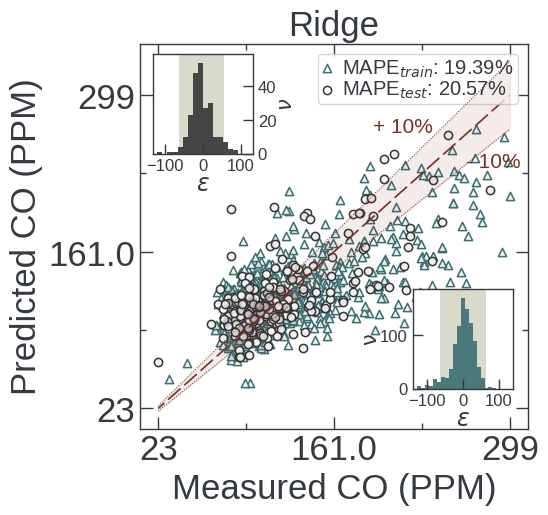

In [7]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = Ridge()
hyperparameter_grid= {'alpha': [0.00001, 0.0001,0.001, 0.1]} 
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = 4, verbose= 2)
random_search.best_params_
end_profiling(save_path = None, note = None)

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= None)
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant4/{titles[2]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[2],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

# Elastic net

GPU 0: Utilization: 0%, Memory Used: 467 MB / 12282 MB
Fitting 1 folds for each of 4 candidates, totalling 4 fits
[CV] END ........................................alpha=1e-05; total time=   0.0s
[CV] END .......................................alpha=0.0001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s


{'alpha': 0.1}

GPU 0: Utilization: 0%, Memory Used: 467 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 467 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 467 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 0.0832 s
System CPU time  : 0.0199 s
Total CPU time   : 0.1031 s
Wall clock time  : 0.5531 s

---- CPU Utilization Stats ----
Avg CPU usage    : 0.00%
Max CPU usage    : 0.00%
Logical cores    : 64
Physical cores   : 32
Avg Training:  R^2 = 0.49, MAE = 23.08, MAPE = 19.44%
Avg Val:  R^2 = 0.37, MAE = 25.05, MAPE = 21.03%
Test 0.44 23.03 20.73


X has feature names, but ElasticNet was fitted without feature names
X has feature names, but ElasticNet was fitted without feature names
X has feature names, but ElasticNet was fitted without feature names


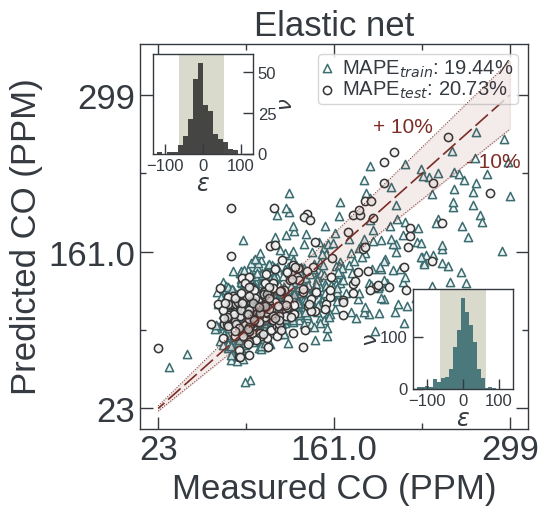

In [8]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = ElasticNet()
hyperparameter_grid= {'alpha': [0.00001, 0.0001,0.001, 0.1]} 
iterations = 4
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = 4, verbose= 2)
random_search.best_params_
end_profiling(save_path = None, note = None)

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= None)
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant4/{titles[3]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[3],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results))  
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

# Random forest

GPU 0: Utilization: 0%, Memory Used: 71 MB / 12282 MB
Fitting 1 folds for each of 100 candidates, totalling 100 fits
[CV] END bootstrap=False, ccp_alpha=0.001, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=4, n_estimators=800; total time=   3.1s
[CV] END bootstrap=True, ccp_alpha=0.001, max_depth=12, max_features=sqrt, min_samples_leaf=2, min_samples_split=32, n_estimators=600; total time=   1.3s
[CV] END bootstrap=True, ccp_alpha=0.0005, max_depth=24, max_features=0.5, min_samples_leaf=12, min_samples_split=16, n_estimators=1000; total time=   5.1s
[CV] END bootstrap=True, ccp_alpha=0.0, max_depth=12, max_features=0.3, min_samples_leaf=8, min_samples_split=2, n_estimators=1000; total time=   3.7s
[CV] END bootstrap=True, ccp_alpha=0.001, max_depth=24, max_features=0.3, min_samples_leaf=12, min_samples_split=2, n_estimators=1000; total time=   3.4s
[CV] END bootstrap=True, ccp_alpha=0.001, max_depth=24, max_features=0.6, min_samples_leaf=8, min_samples_split=4,

{'n_estimators': 200,
 'min_samples_split': 4,
 'min_samples_leaf': 1,
 'max_features': 0.4,
 'max_depth': None,
 'ccp_alpha': 0.0,
 'bootstrap': False}

GPU 0: Utilization: 0%, Memory Used: 71 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 71 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 71 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 318.7009 s
System CPU time  : 0.2758 s
Total CPU time   : 318.9767 s
Wall clock time  : 319.2780 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.56%
Max CPU usage    : 1.64%
Logical cores    : 64
Physical cores   : 32


A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Avg Training:  R^2 = 1.0, MAE = 0.98, MAPE = 0.7%
Avg Val:  R^2 = 0.55, MAE = 19.07, MAPE = 15.76%
Test 0.57 18.28 16.45


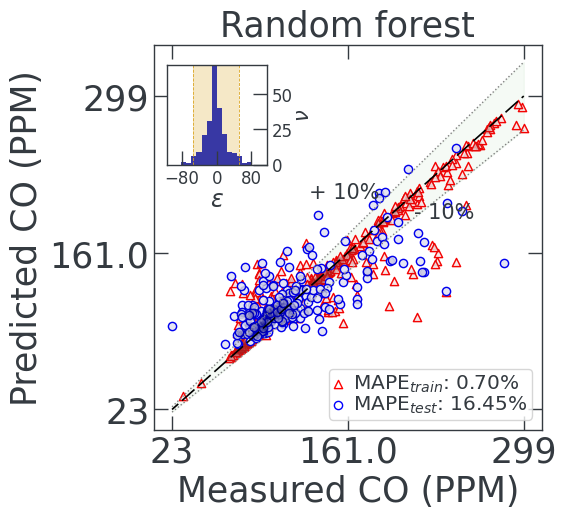

In [ ]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = RandomForestRegressor(random_state=42, n_jobs=-1)
hyperparameter_grid = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [12, 16, 20, 24, None],        # None = grow until pure
    "min_samples_split": [2, 4, 8, 16, 32],
    "min_samples_leaf": [1, 2, 4, 8, 12, 16],
    "max_features": [0.3, 0.4, 0.5, 0.6, "sqrt", "log2"],
    "ccp_alpha": [0.0, 0.0001, 0.0005, 0.001, 0.005],
    "bootstrap": [True, False]
}
iterations =100
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, np.ravel(y_train), # ravel for randomforest
                                                       iterations = iterations, verbose= 1)
random_search.best_params_
end_profiling(save_path = None, note = None)

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = 'palnt4 CO random forest',log_file_path= '/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant4/random_forest.txt')
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)  
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant4/{titles[4]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[4],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

RandomForestRegressor(ccp_alpha=0.001, max_depth=24, max_features=0.6,
                      min_samples_leaf=8, min_samples_split=4,
                      n_estimators=1000, n_jobs=-1, random_state=42)

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Avg Training:  R^2 = 0.73, MAE = 15.04, MAPE = 12.23%
Avg Val:  R^2 = 0.47, MAE = 21.6, MAPE = 17.77%
Test 0.55 19.14 17.52


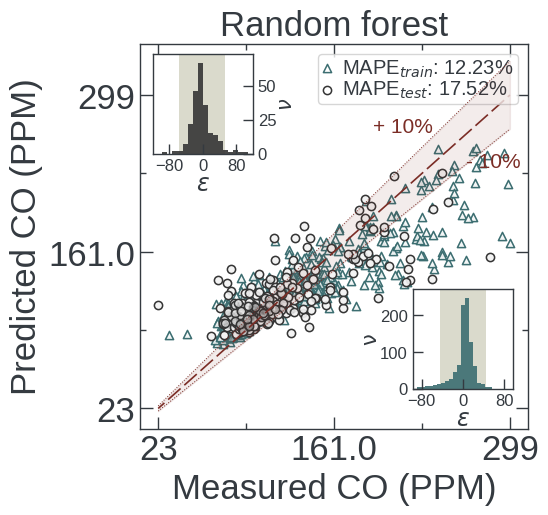

In [9]:
# best model overfit, this model is more genralizable model better
np.random.seed(1002)
random.seed(0)
best_regressor = RandomForestRegressor(n_estimators  = 1000,  min_samples_split  = 4,  min_samples_leaf  = 8, 
                                  max_features  = 0.6,  max_depth  = 24,  ccp_alpha  = 0.001, 
                                  bootstrap  = True, random_state=42, n_jobs=-1)
best_regressor.fit(X_train, np.ravel(y_train))
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant4/{titles[4]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[4],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# XGboost

GPU 0: Utilization: 0%, Memory Used: 582 MB / 12282 MB
Fitting 1 folds for each of 100 candidates, totalling 100 fits
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=5, min_child_weight=9, n_estimators=200, reg_alpha=3, reg_lambda=9, subsample=0.6; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=7, min_child_weight=11, n_estimators=200, reg_alpha=5, reg_lambda=9, subsample=0.6; total time=   0.3s
[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=5, min_child_weight=11, n_estimators=400, reg_alpha=3, reg_lambda=5, subsample=0.9; total time=   0.5s
[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=3, min_child_weight=11, n_estimators=400, reg_alpha=5, reg_lambda=7, subsample=0.9; total time=   0.3s
[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=7, min_child_weight=5, n_estimators=400, reg_alpha=3, reg_lambda=11, subsample=0.9; total time=   0.8s
[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=7,

{'subsample': 0.6,
 'reg_lambda': 5,
 'reg_alpha': 3,
 'n_estimators': 800,
 'min_child_weight': 5,
 'max_depth': 6,
 'learning_rate': 0.05,
 'colsample_bytree': 0.6}

GPU 0: Utilization: 12%, Memory Used: 582 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 582 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 12%, Memory Used: 582 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 62.5852 s
System CPU time  : 0.4160 s
Total CPU time   : 63.0012 s
Wall clock time  : 63.1703 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.55%
Max CPU usage    : 1.59%
Logical cores    : 64
Physical cores   : 32
Avg Training:  R^2 = 1.0, MAE = 0.32, MAPE = 0.28%
Avg Val:  R^2 = 0.53, MAE = 19.19, MAPE = 15.67%
Test 0.62 16.8 15.08


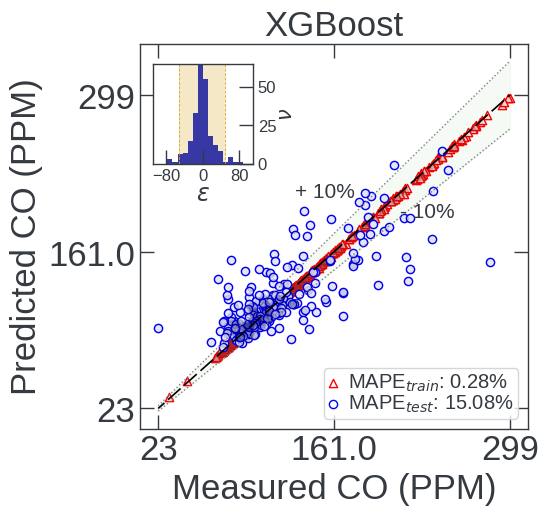

In [ ]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = XGBRegressor(random_state=42, tree_method='gpu_hist', n_jobs=-1)
hyperparameter_grid = {
    "n_estimators": [200, 400, 600, 800],            # more trees but slower learning
    "max_depth": [3, 4, 5, 6, 7],                   # shallower trees → less overfitting
    "min_child_weight": [5, 7, 9, 11],               # larger = less complex splits
    "subsample": [0.6, 0.7, 0.8, 0.9],               # row sampling
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],        # feature sampling
    "learning_rate": [0.01, 0.02, 0.03, 0.05],       # slower learning → needs more trees
    "reg_lambda": [5, 7, 9, 11],                     # L2 regularization
    "reg_alpha": [3, 5, 7, 9]                        # L1 regularization
}
iterations =100
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = iterations, verbose= 2)
random_search.best_params_
end_profiling(save_path = None, note = None)

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = 'palnt4 CO XGBoost',log_file_path= '/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant4/XGboost.txt')
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant4/{titles[5]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[5],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results))  
val_scores.append(tuple(avg_val_results))  
test_scores.append(tuple(test_results))

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.02, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             n_estimators=400, n_jobs=-1, num_parallel_tree=None,
             predictor=None, random_state=42, ...)

Avg Training:  R^2 = 0.87, MAE = 10.41, MAPE = 8.6%
Avg Val:  R^2 = 0.49, MAE = 20.54, MAPE = 16.69%
Test 0.61 17.68 16.25


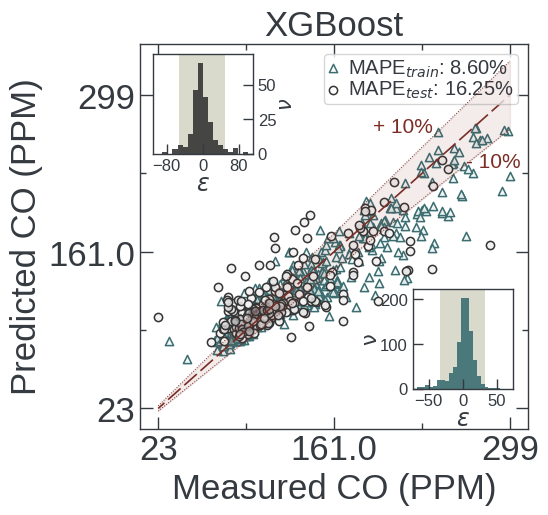

In [10]:
# best model overfit, iteration 76 is more genralizable model better
np.random.seed(1002)
random.seed(0)
best_regressor = XGBRegressor( random_state=42, tree_method='gpu_hist', n_jobs=-1,
subsample= 0.9, reg_lambda= 11, reg_alpha= 5, n_estimators= 400, min_child_weight= 5, max_depth= 4, learning_rate= 0.02, colsample_bytree= 0.6
)
best_regressor.fit(X_train, y_train)
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant4/{titles[5]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[5],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

# best model stats

In [5]:
start_profiling() 

np.random.seed(1002)
random.seed(0)
best_regressor = XGBRegressor( random_state=42, tree_method='gpu_hist', n_jobs=-1,
subsample= 0.9, reg_lambda= 11, reg_alpha= 5, n_estimators= 400, min_child_weight= 5, max_depth= 4, learning_rate= 0.02, colsample_bytree= 0.6
)
best_regressor.fit(X_train, y_train)
train_test_score(best_regressor, X_train, X_test, y_train, y_test)


end_profiling()
save_model(best_regressor,
           model_path =f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant4/xgb_best.pkl') # =None if not want to save

model_size('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant4/xgb_best.pkl')

GPU 0: Utilization: 0%, Memory Used: 207 MB / 12282 MB


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.02, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             n_estimators=400, n_jobs=-1, num_parallel_tree=None,
             predictor=None, random_state=42, ...)

Training 0.86 11.22 9.27
Test 0.61 17.68 16.25
GPU 0: Utilization: 40%, Memory Used: 435 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 207 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 40%, Memory Used: 435 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 0.7092 s
System CPU time  : 0.3100 s
Total CPU time   : 1.0193 s
Wall clock time  : 1.0642 s

---- CPU Utilization Stats ----
Avg CPU usage    : 0.78%
Max CPU usage    : 1.56%
Logical cores    : 64
Physical cores   : 32
Model size: 0.57 MB


# SVR

GPU 0: Utilization: 0%, Memory Used: 582 MB / 12282 MB
Fitting 1 folds for each of 200 candidates, totalling 200 fits


{'model__regressor__tol': 0.01,
 'model__regressor__shrinking': False,
 'model__regressor__kernel': 'rbf',
 'model__regressor__gamma': 'scale',
 'model__regressor__epsilon': 0.001,
 'model__regressor__degree': 2,
 'model__regressor__coef0': 0.5,
 'model__regressor__C': 10}

GPU 0: Utilization: 0%, Memory Used: 582 MB / 12282 MB
---- NOTE ----
RandomSearchCV for plant 4 SVR

---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 582 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 582 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 15.7678 s
System CPU time  : 0.0556 s
Total CPU time   : 15.8234 s
Wall clock time  : 16.0965 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.51%
Max CPU usage    : 1.59%
Logical cores    : 64
Physical cores   : 32
Avg Training:  R^2 = 0.92, MAE = 3.26, MAPE = 2.08%
Avg Val:  R^2 = 0.54, MAE = 18.23, MAPE = 14.57%
Test 0.65 15.51 12.99


X has feature names, but StandardScaler was fitted without feature names
X has feature names, but StandardScaler was fitted without feature names
X has feature names, but StandardScaler was fitted without feature names


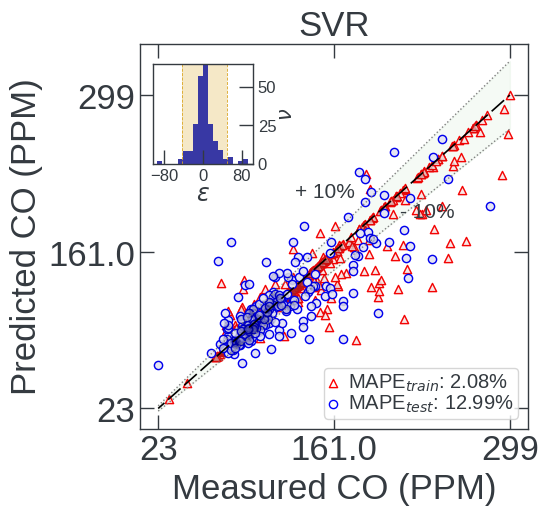

In [ ]:
np.random.seed(1002)
random.seed(0)
start_profiling() 

pipeline = Pipeline([      
    ('scaler_X', StandardScaler()), 
    ('model', TransformedTargetRegressor(
        regressor= SVR(),
        transformer=StandardScaler()))
])
hyperparameter_grid = {
    "kernel":  ["rbf", "poly", "sigmoid"],
    "C":       [0.1, 1, 10, 50, 100, 200, 500],
    "epsilon": [0.001, 0.01, 0.05, 0.1, 0.2, 0.5],
    "gamma":   ["scale", "auto", 1e-4, 1e-3, 1e-2, 1e-1],
    "degree":  [2, 3, 4],          
    "coef0":   [0.0, 0.1, 0.5, 1.0],
    "tol":     [1e-4, 1e-3, 1e-2],
    "shrinking": [True, False]
}

iterations = 200
best_regressor,random_search = RandomSearchCV_pipeline(pipeline, flatten_grid(hyperparameter_grid), X_train, y_train, 
                                                       iterations = iterations, verbose= 1)
random_search.best_params_
end_profiling(save_path = None,
              note = 'RandomSearchCV for plant 4 SVR')

# save_model(best_regressor,
#            model_path =f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant4/svr_best.pkl') # =None if not want to save

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant4/svr.txt")
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant4/{titles[6]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[6],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

Pipeline(steps=[('scaler_X', StandardScaler()),
                ('model',
                 TransformedTargetRegressor(regressor=SVR(C=1, coef0=1.0,
                                                          degree=4, epsilon=0.5,
                                                          kernel='poly',
                                                          shrinking=False,
                                                          tol=0.0001),
                                            transformer=StandardScaler()))])

Avg Training:  R^2 = 0.83, MAE = 14.94, MAPE = 13.24%
Avg Val:  R^2 = 0.37, MAE = 22.58, MAPE = 18.89%
Test 0.59 18.76 16.34


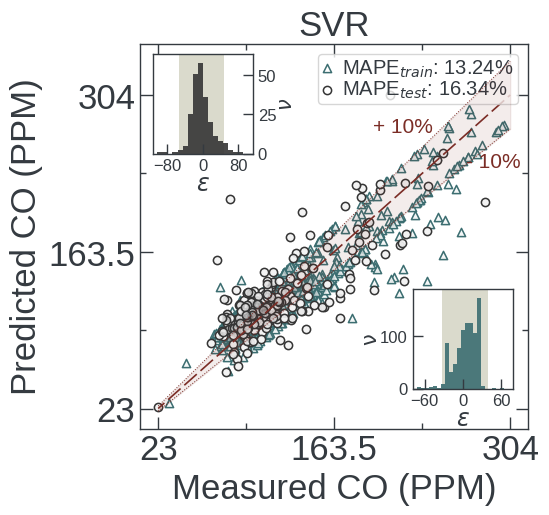

In [11]:
# Iteration 40
regressor = SVR(
tol= 0.0001, shrinking= False, kernel= "poly", gamma= "scale", epsilon= 0.5, degree= 4, coef0= 1.0, C= 1
    )
pipeline = Pipeline([      
    ('scaler_X', StandardScaler()), 
    ('model', TransformedTargetRegressor(
        regressor= regressor,
        transformer=StandardScaler()))
])
pipeline.fit(X_train, y_train)
avg_train_results, avg_val_results = k_fold_scores(pipeline, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant4/{titles[6]}_parity.pdf'
test_results = parity_train_test(pipeline, titles[6],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# GPR

GPU 0: Utilization: 0%, Memory Used: 71 MB / 12282 MB
Fitting 1 folds for each of 200 candidates, totalling 200 fits


The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k1__k1__constant_value is clo

{'model__regressor__normalize_y': False,
 'model__regressor__kernel': 1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1),
 'model__regressor__alpha': 1e-10}

GPU 0: Utilization: 0%, Memory Used: 71 MB / 12282 MB
---- NOTE ----
RandomSearchCV for plant 4 gpr

---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 71 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 71 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 421.6842 s
System CPU time  : 81.8436 s
Total CPU time   : 503.5279 s
Wall clock time  : 503.1664 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.56%
Max CPU usage    : 1.65%
Logical cores    : 64
Physical cores   : 32
Avg Training:  R^2 = 0.98, MAE = 3.53, MAPE = 2.89%
Avg Val:  R^2 = 0.56, MAE = 18.13, MAPE = 14.66%
Test 0.67 16.04 13.98


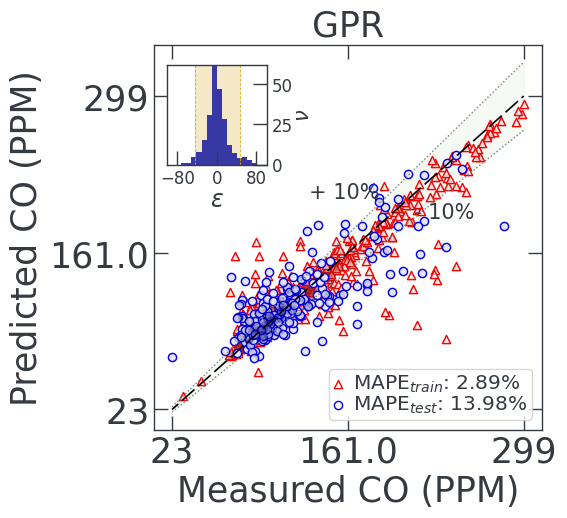

In [ ]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
pipeline = Pipeline([      
    ('scaler_X', StandardScaler()), 
    ('model', TransformedTargetRegressor(
        regressor= GaussianProcessRegressor(random_state=3),
        transformer=StandardScaler()))
])
hyperparameter_grid = {
    "kernel": (
        # Matern + WhiteKernel
        [
            ConstantKernel(1.0, (1e-3, 1e3)) *
            Matern(length_scale=ls, nu=nu) +
            WhiteKernel(noise_level=noise)
            for ls in [0.1, 0.5, 1, 2, 5, 10]
            for nu in [0.5, 1.5, 2.5]
            for noise in [1e-5, 1e-3, 1e-1, 1]
        ]
        +
        # RBF + WhiteKernel
        [
            ConstantKernel(1.0, (1e-3, 1e3)) *
            RBF(length_scale=ls) +
            WhiteKernel(noise_level=noise)
            for ls in [0.1, 0.5, 1, 2, 5, 10]
            for noise in [1e-5, 1e-3, 1e-1, 1]
        ]
        +
        # RationalQuadratic + WhiteKernel
        [
            ConstantKernel(1.0, (1e-3, 1e3)) *
            RationalQuadratic(length_scale=ls, alpha=alpha) +
            WhiteKernel(noise_level=noise)
            for ls in [0.1, 0.5, 1, 2, 5, 10]
            for alpha in [0.1, 0.5, 1, 2]
            for noise in [1e-5, 1e-3, 1e-1, 1]
        ]
    ),
    "alpha": [1e-10, 1e-5, 1e-3, 1e-2, 1e-1, 1],
    "normalize_y": [True, False],
}

iterations =200
best_regressor,random_search = RandomSearchCV_pipeline(pipeline, flatten_grid(hyperparameter_grid), X_train, y_train, 
                                                       iterations = iterations, verbose= 1)
random_search.best_params_
end_profiling(save_path = '/home/m3rg2000/Junaid_temporary/saved_data/Time_cpu_stats/plant4/gpr_rand_SearchCV.txt',
              note = 'RandomSearchCV for plant 4 gpr')

save_model(best_regressor,
           model_path = f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant4/gpr_best.pkl')

# save Randomsearch results
log_search_space(random_search.cv_results_ , file_note = None,log_file_path= "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant4/gpr.txt")
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant4/{titles[7]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[7],'CO (PPM)', X_train, X_test, y_train, y_test, avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results))  
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.


Pipeline(steps=[('scaler_X', StandardScaler()),
                ('model',
                 TransformedTargetRegressor(regressor=GaussianProcessRegressor(alpha=1,
                                                                               kernel=1**2 * RationalQuadratic(alpha=2, length_scale=5) + WhiteKernel(noise_level=0.1),
                                                                               normalize_y=True,
                                                                               random_state=3),
                                            transformer=StandardScaler()))])

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k2__noise_level is close to the spe

Avg Training:  R^2 = 0.62, MAE = 19.33, MAPE = 16.04%
Avg Val:  R^2 = 0.47, MAE = 22.4, MAPE = 18.56%
Test 0.55 19.7 17.54


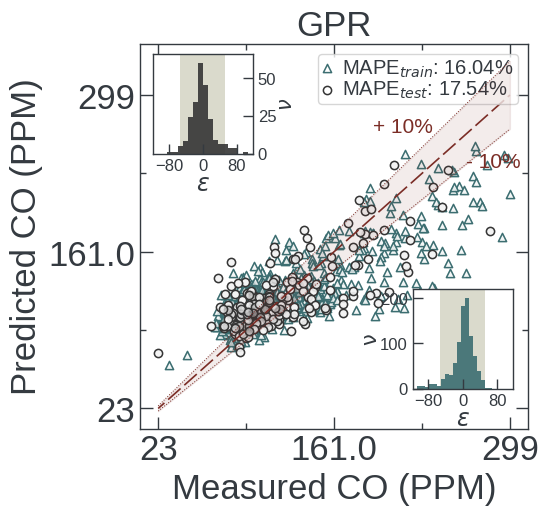

In [12]:
# Iteration 
np.random.seed(1002)
random.seed(0)

regressor = GaussianProcessRegressor(random_state = 3,
normalize_y= True, kernel=1**2 * RationalQuadratic(alpha=2, length_scale=5) + WhiteKernel(noise_level=0.1), alpha = 1)
pipeline = Pipeline([      
    ('scaler_X', StandardScaler()), 
    ('model', TransformedTargetRegressor(
        regressor= regressor,
        transformer=StandardScaler()))
])
pipeline.fit(X_train, y_train)
avg_train_results, avg_val_results = k_fold_scores(pipeline, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant4/{titles[7]}_parity.pdf'
test_results = parity_train_test(pipeline, titles[7],'CO (PPM)', X_train, X_test, y_train, y_test, avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

# NN

GPU 0: Utilization: 0%, Memory Used: 691 MB / 12282 MB
Fitting 1 folds for each of 150 candidates, totalling 150 fits


Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.


{'model__regressor__verbose': False,
 'model__regressor__validation_fraction': 0.2,
 'model__regressor__solver': 'adam',
 'model__regressor__random_state': 42,
 'model__regressor__n_iter_no_change': 20,
 'model__regressor__max_iter': 500,
 'model__regressor__learning_rate_init': 0.0003,
 'model__regressor__hidden_layer_sizes': (128, 64),
 'model__regressor__early_stopping': True,
 'model__regressor__batch_size': 32,
 'model__regressor__alpha': 0.01,
 'model__regressor__activation': 'relu'}

GPU 0: Utilization: 0%, Memory Used: 691 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 691 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 691 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 89.5979 s
System CPU time  : 0.0728 s
Total CPU time   : 89.6707 s
Wall clock time  : 89.7239 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.55%
Max CPU usage    : 1.59%
Logical cores    : 64
Physical cores   : 32
Avg Training:  R^2 = 0.81, MAE = 11.85, MAPE = 9.8%
Avg Val:  R^2 = 0.5, MAE = 21.09, MAPE = 17.54%
Test 0.52 19.51 17.29


X has feature names, but StandardScaler was fitted without feature names
X has feature names, but StandardScaler was fitted without feature names
X has feature names, but StandardScaler was fitted without feature names


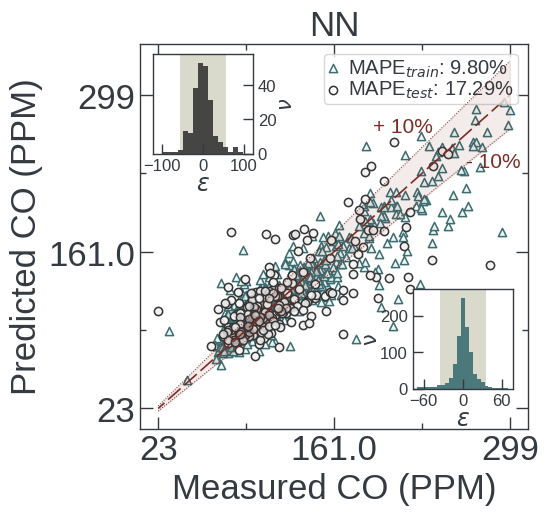

In [13]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
pipeline = Pipeline([      
    ('scaler_X', StandardScaler()), 
    ('model', TransformedTargetRegressor(
        regressor= MLPRegressor(),
        transformer=StandardScaler()))
])
hyperparameter_grid = {
    'hidden_layer_sizes': [
        (64,), (128,), (256,),          # Single layer
        (64, 32), (128, 64), (256, 128), # Two layers
        (128, 64, 32), (64, 32, 16)      # Three layers (only for more data)
    ],
    'activation': ['relu'],
    
    'learning_rate_init': [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    'batch_size': [16, 32, 64, 128],
    'solver': ['adam'],  # 'lbfgs' works better for small datasets, 'adam' for large
    'early_stopping': [True],  # Keep fixed if you're using validation
    'n_iter_no_change': [20],
    'validation_fraction': [0.2],
    'max_iter': [500],
    'random_state': [42], 
    'verbose': [False]
}
iterations =150
best_regressor,random_search = RandomSearchCV_pipeline(pipeline, flatten_grid(hyperparameter_grid), X_train, y_train,  # ravel for NN
                                                       iterations = iterations, verbose= 1)

random_search.best_params_
end_profiling('/home/m3rg2000/Junaid_temporary/saved_data/Time_cpu_stats/plant_compare/plant_4_co.txt')
save_model(best_regressor,
           model_path =f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/plant_compare/best_plant4_co.pkl') # =None if not want to save

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path = "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant4/co_nn.txt")
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant4/{titles[8]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[8],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

In [15]:
train_scores = [(0.49, 23.06, 19.39),
 (0.49, 23.07, 19.41),
 (0.49, 23.06, 19.39),
 (0.49, 23.08, 19.44),
 (0.73, 15.04, 12.23),
 (0.87, 10.41, 8.6),
 (0.83, 14.94, 13.24),
 (0.62, 19.33, 16.04),
 (0.81, 11.85, 9.8)]

val_scores = [(0.37, 25.01, 20.94),
 (0.37, 25.03, 20.98),
 (0.37, 25.01, 20.94),
 (0.37, 25.05, 21.03),
 (0.47, 21.6, 17.77),
 (0.49, 20.54, 16.69),
 (0.37, 22.58, 18.89),
 (0.47, 22.4, 18.56),
 (0.5, 21.09, 17.54)]

test_scores = [(0.44, 23.08, 20.57),
 (0.44, 23.06, 20.66),
 (0.44, 23.08, 20.57),
 (0.44, 23.03, 20.73),
 (0.55, 19.14, 17.52),
 (0.61, 17.68, 16.25),
 (0.59, 18.76, 16.34),
 (0.55, 19.7, 17.54),
 (0.52, 19.51, 17.29)]

with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant4_train.pkl", "wb") as f:  
    pickle.dump(train_scores, f)
    
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant4_val.pkl", "wb") as f:  
    pickle.dump(val_scores, f)
    
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant4_test.pkl", "wb") as f:  
    pickle.dump(test_scores, f)